In [ ]:
import numpy as np
import geopandas as gpd
import pandas as pd

In [26]:
list(range(14))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

In [27]:
np.arange(0, 15)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [68]:
df = pd.read_csv(
        "https://doi.glamos.ch/data/glacier_list/glacier_list.csv",
        skiprows=9,
        parse_dates=True,
        names=[
            "name",
            "id",
            "coordx",
            "coordy",
            "area",
            "survey_year",
            "length_change_data_available",
            "mass_balance_data_available",
            "volume_change_data_available",
        ],
    )

In [69]:
df

,name,id,coordx,coordy,area,survey_year,length_change_data_available,mass_balance_data_available,volume_change_data_available
0,Adlergletscher,B56-14,2634107,1095923,2.098,2015.0,0,1,1
1,Allalingletscher,B52-29,2635415,1097376,9.089,2015.0,1,1,1
2,Alphubelgletscher N,B55-15,2633152,1100698,0.085,2015.0,0,1,0
3,Ammertegletscher,A55f-01,2608024,1140522,0.889,2016.0,1,0,0
4,Bas Glacier d'Arolla,B73-14,2603981,1090382,5.069,2016.0,1,0,0
...,...,...,...,...,...,...,...,...,...
162,Wallenburfirn,A51f-24,2678186,1172930,1.389,2016.0,1,0,0
163,Wildstrubelgletscher,A55c-13,2607564,1138965,2.344,2016.0,1,0,1
164,Witenwasserengletscher,A51e-20,2679432,1153824,0.728,2018.0,1,0,0
165,Zapportgletscher,A13n-04,2726191,1148952,1.311,2015.0,1,0,0


In [70]:
df = df[df['mass_balance_data_available'] == 1][['id', 'coordx', 'coordy']]

In [71]:
mb = pd.read_csv(
        "https://doi.glamos.ch/data/massbalance/massbalance_fixdate.csv",
        skiprows=9,
        parse_dates=True,
        usecols=list(range(8)),
        names=[
            "name",
            "id",
            "observation_start",
            "observation_end_winter",
            "observation_end",
            "mass_balance_winter",
            "mass_balance_summer",
            "mass_balance_annual",
        ],
    )


In [72]:
mb

,name,id,observation_start,observation_end_winter,observation_end,mass_balance_winter,mass_balance_summer,mass_balance_annual
0,Silvrettagletscher,A10g-05,1914-10-01,1915-04-30,1915-09-30,1503,-1918,-415
1,Silvrettagletscher,A10g-05,1915-10-01,1916-04-30,1916-09-30,1415,-1034,381
2,Silvrettagletscher,A10g-05,1916-10-01,1917-04-30,1917-09-30,1872,-1900,-28
3,Silvrettagletscher,A10g-05,1917-10-01,1918-04-30,1918-09-30,1075,-1489,-414
4,Silvrettagletscher,A10g-05,1918-10-01,1919-04-30,1919-09-30,1862,-840,1022
...,...,...,...,...,...,...,...,...
1234,Vadret dal Corvatsch,E23-18,2020-10-01,2021-04-30,2021-09-30,922,-1804,-882
1235,Vadret dal Corvatsch,E23-18,2021-10-01,2022-04-30,2022-09-30,461,-4078,-3617
1236,Vadret dal Corvatsch,E23-18,2022-10-01,2023-04-30,2023-09-30,483,-2077,-1594
1237,Vadret dal Corvatsch,E23-18,2023-10-01,2024-04-30,2024-09-30,1433,-1919,-486


In [73]:
df = pd.merge(mb, df, on="id")[[
        "id",
        "observation_start",
        "observation_end_winter",
        "observation_end",
        "mass_balance_winter",
        "mass_balance_summer",
        "mass_balance_annual",
        "coordx",
        "coordy",
    ]]
df

,id,observation_start,observation_end_winter,observation_end,mass_balance_winter,mass_balance_summer,mass_balance_annual,coordx,coordy
0,A10g-05,1914-10-01,1915-04-30,1915-09-30,1503,-1918,-415,2801722,1192164
1,A10g-05,1915-10-01,1916-04-30,1916-09-30,1415,-1034,381,2801722,1192164
2,A10g-05,1916-10-01,1917-04-30,1917-09-30,1872,-1900,-28,2801722,1192164
3,A10g-05,1917-10-01,1918-04-30,1918-09-30,1075,-1489,-414,2801722,1192164
4,A10g-05,1918-10-01,1919-04-30,1919-09-30,1862,-840,1022,2801722,1192164
...,...,...,...,...,...,...,...,...,...
1234,E23-18,2020-10-01,2021-04-30,2021-09-30,922,-1804,-882,2783300,1143402
1235,E23-18,2021-10-01,2022-04-30,2022-09-30,461,-4078,-3617,2783300,1143402
1236,E23-18,2022-10-01,2023-04-30,2023-09-30,483,-2077,-1594,2783300,1143402
1237,E23-18,2023-10-01,2024-04-30,2024-09-30,1433,-1919,-486,2783300,1143402


<Axes: >

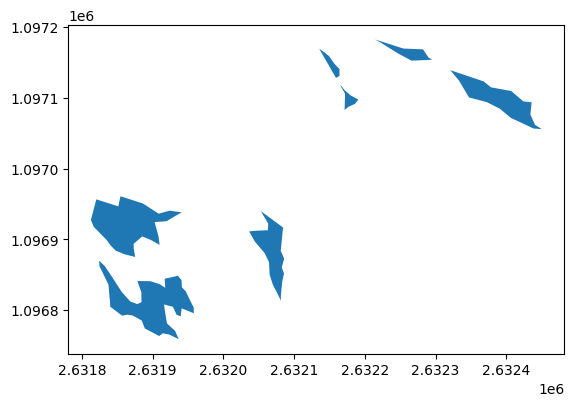

In [32]:
deb = gpd.read_file('SGI_2016_debriscover.shp')
deb[deb['sgi-id'] == 'B55-19'].plot()

<Axes: >

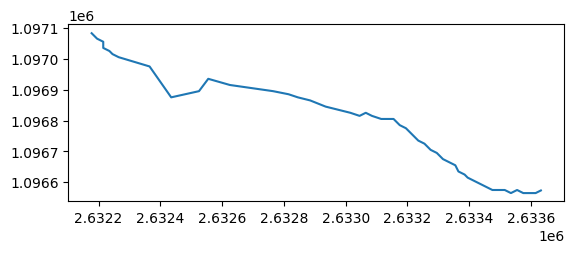

In [33]:
center = gpd.read_file('SGI_2016_centerlines.shp')
center[center['sgi-id'] == 'B55-19'].plot()

In [34]:
gl = gpd.read_file('SGI_2016_glaciers.shp')
gl

,gid,pk_glacier,sgi-id,name,rl_0,rl_1,rl_2,rl_3,i_code,year_acq,year_rel,area_km2,length_km,masl_min,masl_med,masl_mean,masl_max,slope_deg,aspect_deg,geometry
0,16559.0,bb1e06de-74a9-11ea-bc55-0242ac130003,A10g-04,NaN,A,1,0,g,04,2014,2020,0.015169,0.234,3033,3101,3101,3168,32.99,268,"POLYGON ((2802224.865 1193097.586, 2802227.799..."
1,1503.0,80f6be00-4ec8-11e8-85b0-985fd331b2ee,A54e-12,Steigletscher,A,5,4,e,12,2016,2020,5.561256,4.234,2032,2932,2877,3494,20.13,342,"MULTIPOLYGON (((2676375.305 1174502.297, 26763..."
2,17178.0,80e3ab30-4ec8-11e8-9357-985fd331b2ee,A54e-19,Vorder Tierberg (Innertkirchen),A,5,4,e,19,2016,2020,0.578672,1.545,2315,2700,2681,3070,25.43,261,"POLYGON ((2673410.261 1172337.403, 2673426.795..."
3,16556.0,8211f200-4ec8-11e8-9016-985fd331b2ee,A10g-09,Chlein Wintertälli,A,1,0,g,09,2014,2020,0.077443,0.551,2634,2753,2749,2847,28.38,343,"POLYGON ((2798559.905 1190687.342, 2798585.701..."
4,16777.0,809e16ae-4ec8-11e8-a93d-985fd331b2ee,A54j-01,Ochsental,A,5,4,j,01,2016,2020,0.028602,0.322,2118,2191,2191,2268,30.15,332,"POLYGON ((2656707.845 1169768.145, 2656717.484..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395,13019.0,81d6bdc0-4ec8-11e8-b1b1-985fd331b2ee,C83-15,Pass da Casnil,C,8,3,NaN,15,2015,2020,0.011590,0.160,2823,2858,2856,2887,24.76,16,"POLYGON ((2772945.74 1133624.726, 2772947.49 1..."
1396,16824.0,80df8c80-4ec8-11e8-b3e5-985fd331b2ee,A54e-15,Taleggligletscher,A,5,4,e,15,2016,2020,0.246371,0.752,2481,2689,2686,2841,27.74,29,"MULTIPOLYGON (((2672856.354 1174156.594, 26728..."
1397,16117.0,80e09df0-4ec8-11e8-8658-985fd331b2ee,A54e-14,Giglistock,A,5,4,e,14,2016,2020,0.078451,0.390,2720,2793,2790,2863,20.13,96,"POLYGON ((2672857.466 1173500.634, 2672854.581..."
1398,5446.0,80e64340-4ec8-11e8-8e3a-985fd331b2ee,A54e-13,Steilimigletscher,A,5,4,e,13,2016,2020,1.471957,1.952,2104,2832,2826,3322,28.67,10,"MULTIPOLYGON (((2673349.861 1172347.237, 26733..."


<Axes: >

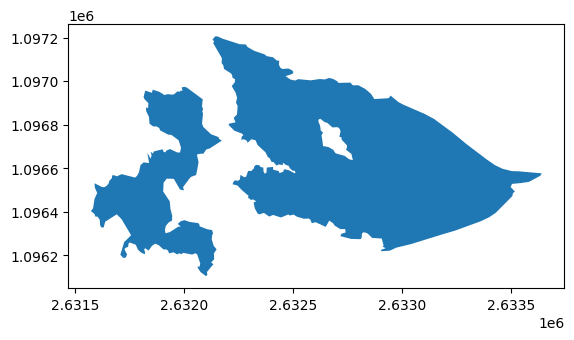

In [35]:
gl[gl['sgi-id'] == 'B55-19'].plot()

In [36]:
ice = gpd.read_file('SGI_2016_icedivides.shp')
ice


,gid,sgi-id_a,name_a,sgi-id_b,name_b,year_acq,year_rel,length_km,geometry
0,1.0,B56-14,Adlergletscher,B52-29,Allalingletscher,2016,2020,0.100,"LINESTRING (2634758.643 1096415.876, 2634764.9..."
1,2.0,B56-14,Adlergletscher,B52-29,Allalingletscher,2016,2020,1.183,"LINESTRING (2634844.522 1096309.752, 2634907.8..."
2,3.0,B52-26,Fluchthorn W,B52-29,Allalingletscher,2016,2020,1.088,"LINESTRING (2636840.561 1096791.493, 2636829.2..."
3,4.0,A51h-13,Firnalpeligletscher SE,A51f-46,StÃ¶ssenfirn E,2016,2020,0.151,"LINESTRING (2678002.236 1180270.64, 2677982.08..."
4,5.0,A51f-23,Flachensteinfirn,A51f-75,Brunnenfirn S,2016,2020,0.116,"LINESTRING (2678669.026 1172014.131, 2678699.1..."
...,...,...,...,...,...,...,...,...,...
356,357.0,B55-19,LÃ¤ngfluegletscher zentral,B55-37,LÃ¤ngfluegletscher,2016,2020,0.800,"LINESTRING (2632947.284 1096933.747, 2632982.7..."
357,358.0,B82-14,Glacier du GiÃ©tro,B74-23,Glacier du Giétro,2016,2020,0.532,"LINESTRING (2597602.807 1093439.352, 2597633.3..."
358,359.0,B56-03,Findelgletscher,B52-65,Findelgletscher,2016,2020,0.230,"LINESTRING (2636103.723 1095082.759, 2636129.8..."
359,360.0,B56-03,Findelgletscher,B52-65,Findelgletscher,2016,2020,0.618,"LINESTRING (2635862.786 1095627.225, 2635872.4..."


<Axes: >

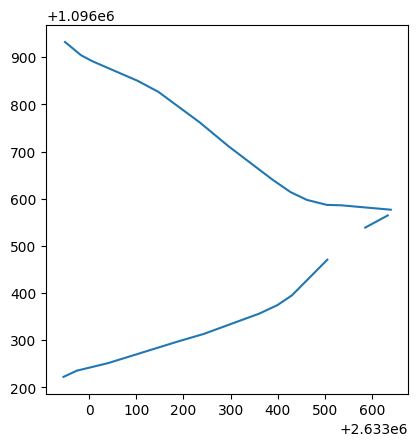

In [37]:
ice[ice['sgi-id_a'] == 'B55-19'].plot()

In [38]:
deb[['sgi-id', 'geometry']]

,sgi-id,geometry
0,B55-19,"POLYGON ((2632177.139 1097087.685, 2632171.381..."
1,B55-19,"POLYGON ((2632440.486 1097062.189, 2632450.279..."
2,B55-19,"POLYGON ((2632164.139 1097131.13, 2632159.194 ..."
3,B55-19,"POLYGON ((2632284.75 1097153.489, 2632266.075 ..."
4,A55f-01,"POLYGON ((2607522.415 1141396.578, 2607599.482..."
...,...,...
4606,B30-28,"POLYGON ((2626884.958 1144576.183, 2626889.881..."
4607,B30-28,"POLYGON ((2626924.548 1144526.954, 2626918.367..."
4608,B30-28,"POLYGON ((2627215.315 1144675.934, 2627215.648..."
4609,B30-28,"POLYGON ((2627188.362 1144739.567, 2627187.767..."


In [44]:
gl[['sgi-id', 'geometry']].to_parquet('../data/glacier_geometry_2013-2018.parquet')

In [46]:
deb[['sgi-id', 'geometry']].to_parquet('../data/debris_geometry_2011-2017.parquet')

In [41]:
deb

,gid,name,sgi-id,year_acq,year_rel,area_km2,geometry
0,1.0,Längfluegletscher zentral,B55-19,2016,2020,0.000277,"POLYGON ((2632177.139 1097087.685, 2632171.381..."
1,2.0,Längfluegletscher zentral,B55-19,2016,2020,0.003119,"POLYGON ((2632440.486 1097062.189, 2632450.279..."
2,3.0,Längfluegletscher zentral,B55-19,2016,2020,0.000316,"POLYGON ((2632164.139 1097131.13, 2632159.194 ..."
3,4.0,Längfluegletscher zentral,B55-19,2016,2020,0.000721,"POLYGON ((2632284.75 1097153.489, 2632266.075 ..."
4,5.0,Ammertegletscher E,A55f-01,2016,2020,0.286544,"POLYGON ((2607522.415 1141396.578, 2607599.482..."
...,...,...,...,...,...,...,...
4606,4607.0,NaN,B30-28,2017,2020,0.000613,"POLYGON ((2626884.958 1144576.183, 2626889.881..."
4607,4608.0,NaN,B30-28,2017,2020,0.000227,"POLYGON ((2626924.548 1144526.954, 2626918.367..."
4608,4609.0,NaN,B30-28,2017,2020,0.000819,"POLYGON ((2627215.315 1144675.934, 2627215.648..."
4609,4610.0,NaN,B30-28,2017,2020,0.000590,"POLYGON ((2627188.362 1144739.567, 2627187.767..."


In [45]:
deb.describe()

,gid,year_acq,year_rel,area_km2
count,4611.000000,4611.000000,4611.0,4611.000000
mean,2306.000000,2015.422468,2020.0,0.022594
std,1331.225375,1.460918,0.0,0.166292
min,1.000000,2011.000000,2020.0,0.000100
25%,1153.500000,2015.000000,2020.0,0.001023
50%,2306.000000,2016.000000,2020.0,0.002822
75%,3458.500000,2016.000000,2020.0,0.009428
max,4611.000000,2017.000000,2020.0,7.055734
